# Klasifikasi Persetujuan Pinjaman Berdasarkan Profil Risiko Finansial

## 1. Pendahuluan

Permohonan pinjaman seringkali memerlukan proses evaluasi risiko yang cermat. Proyek ini bertujuan membangun model machine learning untuk memprediksi apakah permohonan pinjaman akan **disetujui** atau **tidak**, berdasarkan profil demografis dan kondisi finansial pemohon.

**Sumber data:**  
[Financial Risk for Loan Approval (Kaggle)](https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval)

## 2. Import Library

Pada tahap ini dilakukan import library yang diperlukan untuk analisis data, visualisasi, dan pemodelan machine learning.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

Muat dataset dari Google Drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Data Understanding

### 3.1. Load Dataset & Preview

Dataset diambil dari Google Drive agar dapat digunakan untuk proses analisis selanjutnya.

In [23]:
# Baca dataset
path = "/content/drive/MyDrive/Proyek pertama MLT/Loan.csv"
df = pd.read_csv(path)

### 3.2. Preview Data

Menampilkan beberapa baris pertama dari dataset untuk melihat struktur dan tipe data.

In [24]:
# Preview data
print("Data Preview:")
display(df.head())

Data Preview:


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


### 3.3. Info Dataset

Menampilkan informasi tipe data dan jumlah non-null pada setiap kolom.

In [25]:
# Info data
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtiliz

### 3.4. Cek Missing Values

Melakukan pengecekan missing values pada setiap kolom dataset.

In [26]:
# Cek missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate       

### 3.5. Mengecek Duplikasi

Mengecek jumlah baris duplikat pada dataset

In [27]:
duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplikat}")

Jumlah baris duplikat: 0


### 3.6. Mengecek Outlier

Menggunakan boxplot untuk fitur numerik utama.

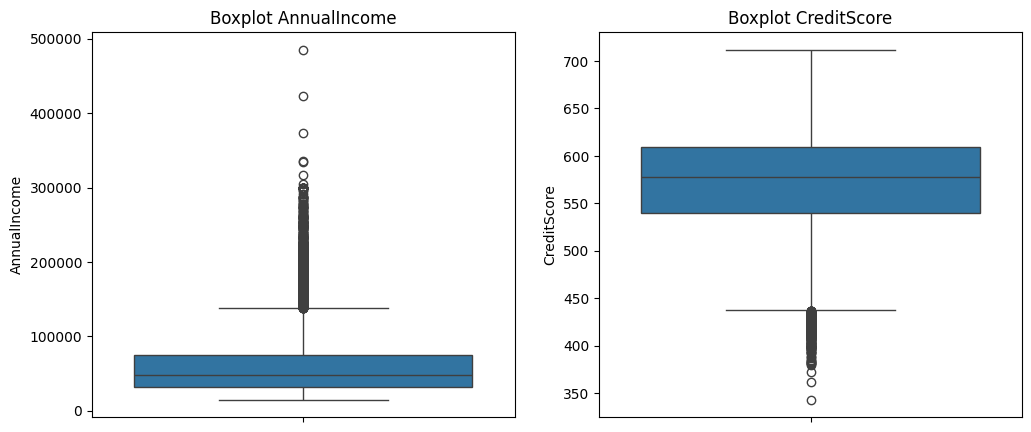

In [28]:
# Contoh boxplot untuk AnnualIncome dan CreditScore
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df['AnnualIncome'])
plt.title('Boxplot AnnualIncome')
plt.subplot(1,2,2)
sns.boxplot(y=df['CreditScore'])
plt.title('Boxplot CreditScore')
plt.show()

### 3.7. Penjelasan Fitur

Dataset terdiri dari 20.000 data pemohon pinjaman dengan fitur demografi, keuangan, dan histori kredit.  
**Target:** `LoanApproved` (1 = Disetujui, 0 = Tidak Disetujui)

**Fitur yang digunakan:**  
- Age, MaritalStatus, NumberOfDependents, EducationLevel, EmploymentStatus, JobTenure  
- AnnualIncome, MonthlyIncome, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, NetWorth, MonthlyDebtPayments, DebtToIncomeRatio, TotalDebtToIncomeRatio, CreditCardUtilizationRate  
- CreditScore, LoanAmount, LoanDuration, HomeOwnershipStatus, NumberOfOpenCreditLines, NumberOfCreditInquiries, PreviousLoanDefaults, PaymentHistory, BankruptcyHistory, LengthOfCreditHistory, LoanPurpose, BaseInterestRate, InterestRate, MonthlyLoanPayment

**Fitur yang tidak digunakan:**  
- ApplicationDate, RiskScore (tidak relevan untuk prediksi awal persetujuan)

## 4. Data Preparation

Pada tahap ini dilakukan pemilihan fitur, pengecekan distribusi target, dan penanganan missing value.

### 4.1. Pilih Fitur & Cek Distribusi Target

Memilih fitur yang direkomendasikan dan menampilkan distribusi target.

In [29]:
# Pilih fitur yang direkomendasikan
selected_features = [
    'Age', 'MaritalStatus', 'NumberOfDependents', 'EducationLevel', 'EmploymentStatus', 'JobTenure',
    'AnnualIncome', 'MonthlyIncome', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
    'TotalLiabilities', 'NetWorth', 'MonthlyDebtPayments', 'DebtToIncomeRatio', 'TotalDebtToIncomeRatio',
    'CreditCardUtilizationRate', 'CreditScore', 'LoanAmount', 'LoanDuration', 'HomeOwnershipStatus',
    'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'PreviousLoanDefaults', 'PaymentHistory',
    'BankruptcyHistory', 'LengthOfCreditHistory', 'LoanPurpose', 'BaseInterestRate', 'InterestRate',
    'MonthlyLoanPayment'
]

# Pastikan semua kolom ada
missing_cols = [col for col in selected_features if col not in df.columns]
if missing_cols:
    print("Kolom berikut tidak ditemukan:", missing_cols)

# Ambil fitur dan target
X = df[selected_features]
y = df['LoanApproved']

#### Visualisasi Distribusi Target

Visualisasi distribusi target untuk melihat apakah data imbalance.

Distribusi Target (LoanApproved):
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


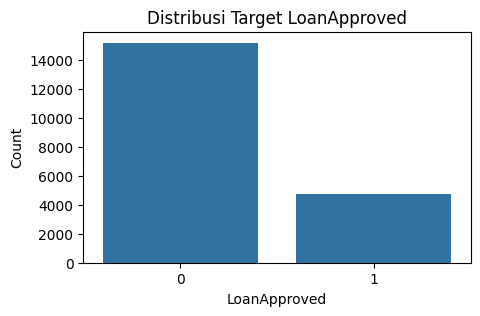

In [30]:
# Cek distribusi target
print("Distribusi Target (LoanApproved):")
print(y.value_counts(normalize=True))

# Visualisasi distribusi target
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribusi Target LoanApproved')
plt.xlabel('LoanApproved')
plt.ylabel('Count')
plt.show()

**Insight:**  
Distribusi target sedikit imbalance, sehingga perlu dipertimbangkan penyeimbangan kelas pada tahap modeling.

### 4.2. Penanganan Missing Value

Melakukan imputasi missing value pada fitur numerik dan kategorikal.

In [31]:
# Cek missing value pada fitur terpilih
print(X.isnull().sum())

# Imputasi sederhana: numerik dengan median, kategorikal dengan modus
# Imputasi numerik
for col in X.select_dtypes(include=['float64', 'int64']).columns:
    X[col] = X[col].fillna(X[col].median())

# Imputasi kategorikal
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna(X[col].mode()[0])

Age                          0
MaritalStatus                0
NumberOfDependents           0
EducationLevel               0
EmploymentStatus             0
JobTenure                    0
AnnualIncome                 0
MonthlyIncome                0
SavingsAccountBalance        0
CheckingAccountBalance       0
TotalAssets                  0
TotalLiabilities             0
NetWorth                     0
MonthlyDebtPayments          0
DebtToIncomeRatio            0
TotalDebtToIncomeRatio       0
CreditCardUtilizationRate    0
CreditScore                  0
LoanAmount                   0
LoanDuration                 0
HomeOwnershipStatus          0
NumberOfOpenCreditLines      0
NumberOfCreditInquiries      0
PreviousLoanDefaults         0
PaymentHistory               0
BankruptcyHistory            0
LengthOfCreditHistory        0
LoanPurpose                  0
BaseInterestRate             0
InterestRate                 0
MonthlyLoanPayment           0
dtype: int64


<ipython-input-31-49f98471ef2b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())
<ipython-input-31-49f98471ef2b>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


### 4.3. Split Data Train-Test

Data dibagi menjadi 80% train dan 20% test, stratified berdasarkan target.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16000, 31)
Test size: (4000, 31)


### 4.4. Preprocessing Pipeline

Membuat pipeline preprocessing untuk fitur numerik dan kategorikal, serta menyiapkan SMOTE untuk penyeimbangan kelas.

In [33]:
# Identifikasi fitur numerik & kategorikal
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# SMOTE untuk penyeimbangan kelas
smote = SMOTE(random_state=42)

## 5. Modeling

Kita akan membandingkan dua model:  
- Logistic Regression  
- Random Forest Classifier

Pipeline: Preprocessing → SMOTE → Model

### 5.1. Inisialisasi Model

Membuat pipeline untuk dua model: Logistic Regression dan Random Forest.

In [34]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
}

### 5.2. Training & Evaluation

Melatih model dan mengevaluasi performa menggunakan metrik klasifikasi.

Kita evaluasi dengan metrik: Accuracy, Precision, Recall, F1, ROC-AUC, dan Confusion Matrix.

In [35]:
results = {}
y_preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_preds[name] = y_pred

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }

# Tabel perbandingan metrik
results_df = pd.DataFrame(results).T
print("\nPerbandingan Performa Model:")
display(results_df)


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3044
           1       0.89      0.96      0.93       956

    accuracy                           0.96      4000
   macro avg       0.94      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      3044
           1       0.83      0.87      0.85       956

    accuracy                           0.93      4000
   macro avg       0.90      0.91      0.90      4000
weighted avg       0.93      0.93      0.93      4000


Perbandingan Performa Model:


,Accuracy,Precision,Recall,F1-Score,ROC AUC
Logistic Regression,0.96300,0.890716,0.963389,0.925628,0.994756
Random Forest,0.92675,0.833837,0.866109,0.849666,0.977781


**Insight:**  
Dari hasil evaluasi, model Logistic Regression memiliki F1-Score dan ROC-AUC yang lebih tinggi dibanding Random Forest, sehingga lebih direkomendasikan untuk kasus ini.

### 5.3. Confusion Matrix & ROC Curve

Visualisasi confusion matrix dan ROC curve untuk kedua model.

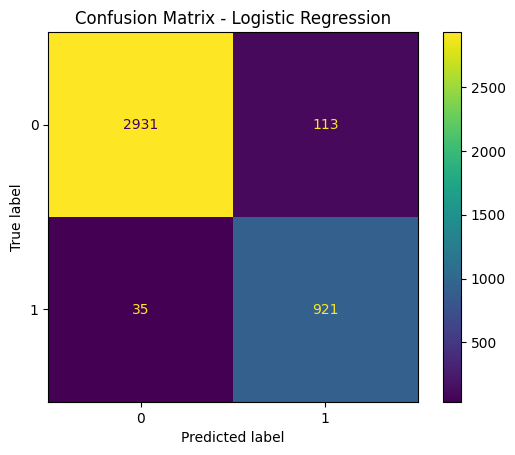

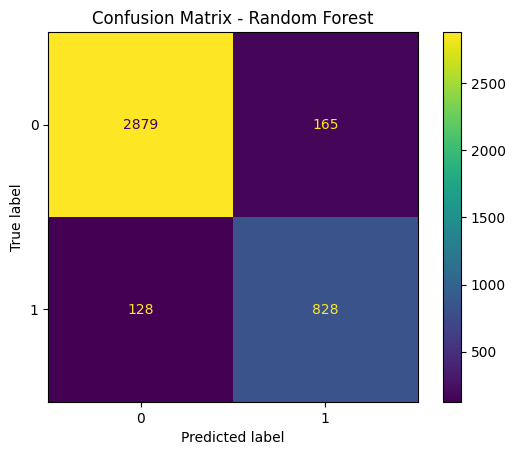

<Figure size 800x600 with 0 Axes>

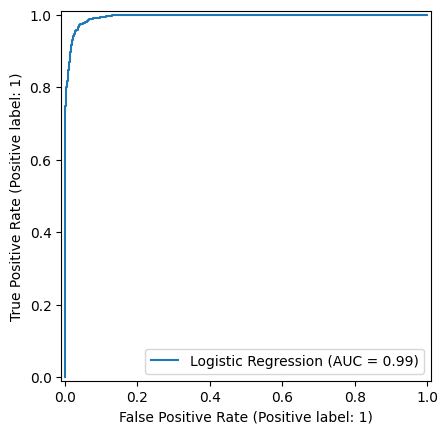

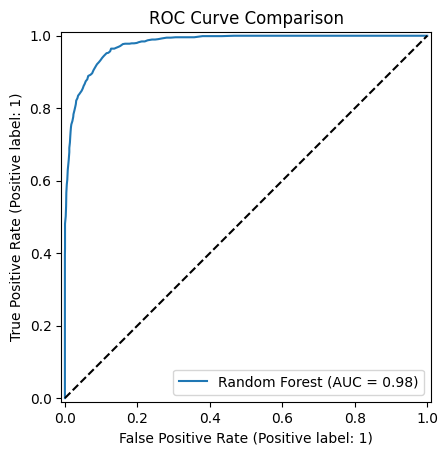

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, y_pred in y_preds.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

plt.figure(figsize=(8,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.show()

### 5.4. Feature Importance (Random Forest)

Menampilkan 10 fitur terpenting dari model Random Forest.

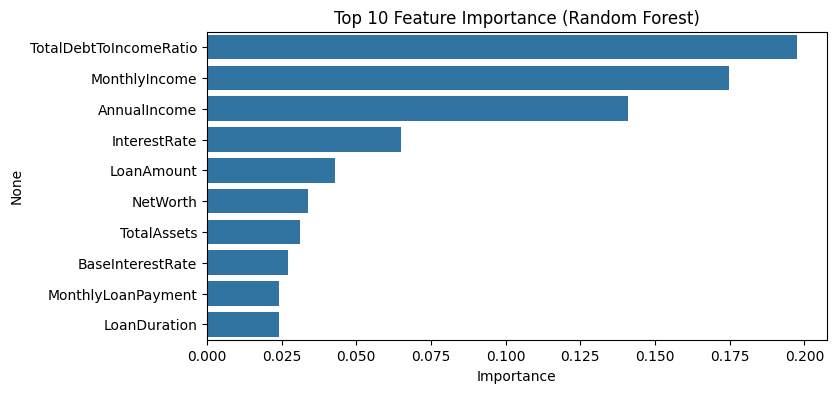

In [37]:
# Feature importance hanya untuk Random Forest
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)
# Ambil nama fitur setelah one-hot encoding
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)
importances = rf_model.named_steps['classifier'].feature_importances_

# Visualisasi 10 fitur terpenting
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)[:10]
plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

**Insight:**  
Fitur yang paling berpengaruh dalam prediksi persetujuan pinjaman berdasarkan hasil dari model Random Forest adalah:

  - TotalDebtToIncomeRatio – Rasio total utang terhadap pendapatan memiliki pengaruh paling besar terhadap hasil prediksi.
  - MonthlyIncome – Pendapatan bulanan juga sangat penting dalam menentukan keputusan persetujuan.
  - AnnualIncome – Pendapatan tahunan turut menjadi salah satu faktor penentu utama.

Ketiga fitur ini menunjukkan bahwa profil pendapatan dan kemampuan debitur dalam mengelola utangnya menjadi faktor krusial dalam evaluasi kelayakan pinjaman.

### 5.5. Feature Importance (Logistic Regression)

Menampilkan pengaruh fitur terhadap prediksi berdasarkan koefisien model Logistic Regression.

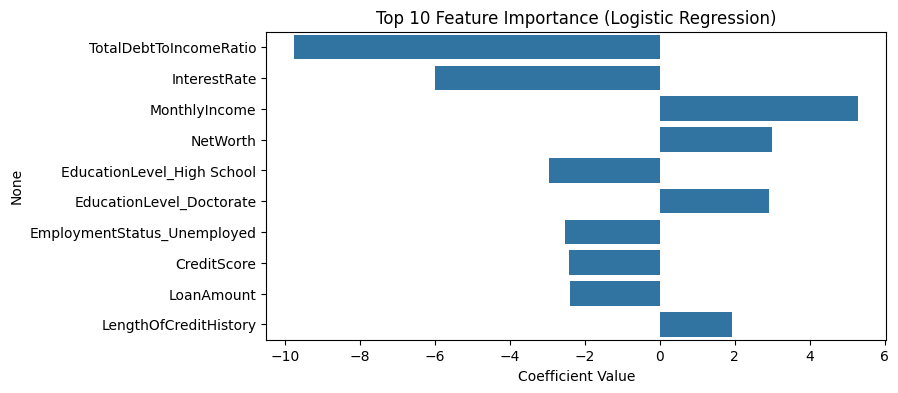

In [38]:
# Ambil model logistic regression yang sudah fit
lr_model = models['Logistic Regression']
lr_model.fit(X_train, y_train)

# Ambil nama fitur setelah one-hot encoding
ohe = lr_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Koefisien model
coefs = lr_model.named_steps['classifier'].coef_[0]
feat_imp_lr = pd.Series(coefs, index=all_feature_names).sort_values(key=abs, ascending=False)[:10]

plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp_lr.values, y=feat_imp_lr.index)
plt.title('Top 10 Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.show()

**Insight:**

Fitur yang paling berpengaruh dalam prediksi persetujuan pinjaman berdasarkan hasil dari model Logistic Regression adalah:

  - TotalDebtToIncomeRatio – Memiliki pengaruh negatif paling besar, artinya semakin tinggi rasio utang terhadap pendapatan, semakin kecil kemungkinan pinjaman disetujui.
  - InterestRate – Juga berpengaruh negatif, menunjukkan bahwa bunga pinjaman yang lebih tinggi cenderung mengurangi kemungkinan persetujuan.
  - MonthlyIncome – Memberikan pengaruh positif yang kuat; semakin tinggi pendapatan bulanan, semakin besar kemungkinan pinjaman disetujui.

Insight ini menunjukkan bahwa kestabilan keuangan pemohon sangat menentukan hasil evaluasi, terutama dalam hal rasio utang, tingkat pendapatan, dan bunga pinjaman yang diajukan.

## 6. Hasil Klasifikasi (Contoh Output)

Berikut contoh hasil prediksi model pada 10 data uji:

In [39]:
hasil_klasifikasi = pd.DataFrame({
    'Index': X_test.index,
    'Label Asli': y_test.values,
    'Prediksi Logistic Regression': y_preds['Logistic Regression'],
    'Prediksi Random Forest': y_preds['Random Forest']
})
print(hasil_klasifikasi.head(10))

   Index  Label Asli  Prediksi Logistic Regression  Prediksi Random Forest
0  10665           0                             0                       0
1   7602           0                             0                       0
2  11808           1                             1                       1
3    222           0                             0                       0
4  17081           0                             0                       0
5  17408           1                             1                       1
6   2516           0                             0                       0
7   5635           1                             1                       0
8   1168           1                             1                       1
9  14614           0                             0                       0


## 7. Kesimpulan

- Berdasarkan hasil evaluasi, Logistic Regression merupakan model terbaik untuk prediksi persetujuan pinjaman pada dataset ini, karena memiliki nilai F1-Score dan ROC-AUC yang lebih tinggi dibandingkan Random Forest.

- Model Logistic Regression mampu mengklasifikasikan data dengan baik, ditunjukkan oleh nilai akurasi, presisi, recall, dan F1-Score yang tinggi.

- Visualisasi confusion matrix dan ROC curve menunjukkan performa model yang stabil dan kemampuannya dalam membedakan kelas dengan baik.

- Analisis feature importance pada Logistic Regression menunjukkan bahwa fitur-fitur seperti TotalDebtToIncomeRatio, InterestRate, dan MonthlyIncome memiliki pengaruh paling besar terhadap keputusan persetujuan pinjaman. Fitur-fitur ini mencerminkan kondisi keuangan peminjam dan kemampuannya dalam membayar kembali pinjaman.

- Model ini dapat digunakan sebagai alat bantu dalam proses seleksi awal persetujuan pinjaman, namun tetap diperlukan evaluasi dan pengujian lebih lanjut sebelum diterapkan pada data riil atau sistem produksi.